In [1]:
import numpy as np
from scipy.optimize import minimize, Bounds

In [2]:
# main.py
"""
Improved deterministic optimisation for 26 circles in a unit square.

Goal
----
Surpass the previous best combined score of 2.63017193736293.

Strategy
--------
1. **Broader multi‑start exploration** – 50 deterministic seeds with a
   larger jitter (±0.08) to sample a wider variety of centre configurations.
2. **Longer SLSQP runs** – 8000 iterations for the multi‑start phase and
   30 000 iterations for the final refinement (still well inside the 120 s
   limit on the evaluation machine).
3. **Greedy hill‑climbing** – after the final SLSQP we repeatedly
   perturb the best centre set (≈4 000 tiny moves) and re‑solve the exact
   LP for the radii, keeping any improvement.  The perturbation scale
   gradually shrinks, mimicking a deterministic “annealing” schedule.
4. **One last short SLSQP polish** – a final 5000‑iteration SLSQP run on the
   best layout found by hill‑climbing to capture any remaining continuous
   improvements.

All I/O and the public entry point (`run_packing`) are unchanged.
"""

import numpy as np
from scipy.optimize import minimize, linprog

# ----------------------------------------------------------------------
# Global constants
# ----------------------------------------------------------------------
N = 26                         # number of circles
SEEDS = list(range(50))        # deterministic seeds for the multi‑start phase
MAX_ITER_SLSQP_MAIN = 8000    # iterations for the main SLSQP runs
MAX_ITER_SLSQP_FINAL = 30000  # iterations for the final refinement
MAX_ITER_SLSQP_LAST = 5000    # iterations for the final short polish
MAX_RADIUS = 0.5               # upper bound for radii (never reached)

# ----------------------------------------------------------------------
# Helper: deterministic hexagonal grid (unchanged)
# ----------------------------------------------------------------------
def _hex_initial_centres():
    """Generate a deterministic hexagonal layout that contains at least N points."""
    step = 0.2                     # spacing – same order as the original grid step
    offset = step / 2.0            # horizontal offset for odd rows

    points = []
    y = step / 2.0
    while y < 1.0:
        row_offset = 0.0 if (int(y / step) % 2 == 0) else offset
        x = step / 2.0 + row_offset
        while x < 1.0:
            points.append((x, y))
            x += step
        y += step * np.sqrt(3) / 2.0

    if len(points) < N:
        points = []
        for i in range(5):
            for j in range(5):
                points.append((step / 2 + j * step, step / 2 + i * step))
        points.append((step / 2 + step / 2, step / 2 + step / 2))

    pts = np.array(points[:N], dtype=float)
    return np.clip(pts, 0.0, 1.0)


# ----------------------------------------------------------------------
# Build SLSQP constraints (identical to the original implementation)
# ----------------------------------------------------------------------
def _build_constraints():
    """Create inequality constraints for the optimiser."""
    constraints = []

    # containment constraints (circle stays inside the square)
    for i in range(N):
        constraints.append({
            "type": "ineq",
            "fun": lambda v, i=i: v[2 * i] - v[2 * N + i] - 1e-12   # x_i - r_i >= 0
        })
        constraints.append({
            "type": "ineq",
            "fun": lambda v, i=i: 1.0 - v[2 * i] - v[2 * N + i] - 1e-12   # 1 - x_i - r_i >= 0
        })
        constraints.append({
            "type": "ineq",
            "fun": lambda v, i=i: v[2 * i + 1] - v[2 * N + i] - 1e-12   # y_i - r_i >= 0
        })
        constraints.append({
            "type": "ineq",
            "fun": lambda v, i=i: 1.0 - v[2 * i + 1] - v[2 * N + i] - 1e-12   # 1 - y_i - r_i >= 0
        })

    # pairwise non‑overlap constraints
    for i in range(N):
        for j in range(i + 1, N):
            def make_fun(i, j):
                def f(v):
                    xi = v[2 * i]
                    yi = v[2 * i + 1]
                    xj = v[2 * j]
                    yj = v[2 * j + 1]
                    ri = v[2 * N + i]
                    rj = v[2 * N + j]
                    return (xi - xj) ** 2 + (yi - yj) ** 2 - (ri + rj) ** 2 - 1e-12
                return f
            constraints.append({
                "type": "ineq",
                "fun": make_fun(i, j)
            })
    return constraints


# ----------------------------------------------------------------------
# Exact tightening for a *fixed* centre configuration (LP)
# ----------------------------------------------------------------------
def _lp_optimal_radii(centres: np.ndarray):
    """
    Solve the linear programme:
        maximise   Σ r_i
        s.t.       0 ≤ r_i ≤ min(x_i, 1‑x_i, y_i, 1‑y_i)
                   r_i + r_j ≤ d_ij   (i < j)

    Returns
    -------
    radii : np.ndarray, shape (N,)
        Radii achieving the optimal sum (clipped to ≥0).
    total : float
        Σ radii.
    """
    x = centres[:, 0]
    y = centres[:, 1]
    ub = np.minimum.reduce([x, 1.0 - x, y, 1.0 - y])

    pairs = [(i, j) for i in range(N) for j in range(i + 1, N)]
    m = len(pairs)

    A = np.zeros((m, N), dtype=float)
    b = np.empty(m, dtype=float)

    for idx, (i, j) in enumerate(pairs):
        A[idx, i] = 1.0
        A[idx, j] = 1.0
        b[idx] = np.hypot(centres[i, 0] - centres[j, 0],
                         centres[i, 1] - centres[j, 1])

    c = -np.ones(N, dtype=float)          # maximise Σ r → minimise -Σ r
    bounds = [(0.0, ub[i]) for i in range(N)]

    res = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method="highs")
    if not res.success:
        return np.zeros(N, dtype=float), 0.0

    radii = np.maximum(res.x, 0.0)
    total = float(np.sum(radii))
    return radii, total


# ----------------------------------------------------------------------
# Core optimisation routine
# ----------------------------------------------------------------------
def construct_packing():
    """Run the full optimisation pipeline and return the best layout."""
    best_total = -1.0
    best_centres = None
    best_radii = None

    base_centres = _hex_initial_centres()
    bounds = [(0.0, 1.0) for _ in range(2 * N)] + [(0.0, MAX_RADIUS) for _ in range(N)]
    constraints = _build_constraints()
    objective = lambda v: -np.sum(v[2 * N:])   # maximise total radius

    # -------------------- Multi‑start SLSQP --------------------
    for seed in SEEDS:
        rng = np.random.default_rng(seed)

        jitter = rng.uniform(-0.08, 0.08, size=base_centres.shape)
        centres0 = np.clip(base_centres + jitter, 0.0, 1.0)

        radii0 = np.full(N, 0.14, dtype=float)   # slightly larger start radius
        x0 = np.concatenate([centres0.ravel(), radii0])

        res = minimize(
            objective,
            x0,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"maxiter": MAX_ITER_SLSQP_MAIN, "ftol": 1e-12, "disp": False},
        )
        if not res.success:
            continue

        centres_opt = res.x[: 2 * N].reshape(N, 2)
        radii_opt, total_opt = _lp_optimal_radii(centres_opt)

        if total_opt > best_total:
            best_total = total_opt
            best_centres = centres_opt
            best_radii = radii_opt

    # -------------------- Final long SLSQP refinement --------------------
    if best_centres is not None:
        x_start = np.concatenate([best_centres.ravel(), best_radii])
        res_final = minimize(
            objective,
            x_start,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"maxiter": MAX_ITER_SLSQP_FINAL, "ftol": 1e-12, "disp": False},
        )
        if res_final.success:
            centres_f = res_final.x[: 2 * N].reshape(N, 2)
            radii_f, total_f = _lp_optimal_radii(centres_f)
            if total_f > best_total:
                best_total = total_f
                best_centres = centres_f
                best_radii = radii_f

    # -------------------- Deterministic greedy hill‑climbing --------------------
    if best_centres is not None:
        # A deterministic RNG for reproducibility
        rng = np.random.default_rng(42)

        # Number of hill‑climb steps and a schedule for the perturbation scale
        steps = 4000
        for step in range(steps):
            # Perturbation magnitude shrinks linearly to 0.001
            scale = 0.018 * (1.0 - step / steps) + 0.001
            proposal = best_centres + rng.normal(scale=scale, size=best_centres.shape)
            proposal = np.clip(proposal, 0.0, 1.0)

            radii_prop, total_prop = _lp_optimal_radii(proposal)

            # Accept only strict improvements (tiny tolerance to avoid noise)
            if total_prop > best_total + 1e-7:
                best_total = total_prop
                best_centres = proposal
                best_radii = radii_prop

    # -------------------- One last short SLSQP polish --------------------
    if best_centres is not None:
        x_last = np.concatenate([best_centres.ravel(), best_radii])
        res_last = minimize(
            objective,
            x_last,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"maxiter": MAX_ITER_SLSQP_LAST, "ftol": 1e-12, "disp": False},
        )
        if res_last.success:
            centres_last = res_last.x[: 2 * N].reshape(N, 2)
            radii_last, total_last = _lp_optimal_radii(centres_last)
            if total_last > best_total:
                best_total = total_last
                best_centres = centres_last
                best_radii = radii_last

    # -------------------- Fallback (very unlikely) --------------------
    if best_centres is None:
        step = 0.2
        best_centres = np.array(
            [(step / 2 + j * step, step / 2 + i * step)
             for i in range(5) for j in range(5)]
        )
        best_radii = np.full(N, 0.1, dtype=float)
        best_total = float(np.sum(best_radii))

    return best_centres, best_radii, best_total


# This part remains fixed (not evolved)
def run_packing():
    """Run the circle packing constructor for n=26"""
    centers, radii, _ = construct_packing()
    # Calculate the sum of radii
    sum_radii = np.sum(radii)
    return centers, radii, sum_radii


np.random.seed(7)
centers, radii, sum_radii = run_packing()
print(sum_radii)

2.635983084915219


In [3]:
def validate_packing(centers, radii, atol=1e-10):
    if not isinstance(centers, np.ndarray):
        centers = np.array(centers)
    if not isinstance(radii, np.ndarray):
        radii = np.array(radii)

    if centers.shape != (N, 2):
        return False, f"Centers shape incorrect. Expected ({N}, 2), got {centers.shape}"
    if radii.shape != (N,):
        return False, f"Radii shape incorrect. Expected ({N},), got {radii.shape}"

    if np.any(np.isnan(centers)) or np.any(np.isnan(radii)):
        return False, "NaN values in output"

    if np.any(radii < 0):
        return False, f"Negative radii found at indices: {np.where(radii < 0)[0]}"

    for i in range(N):
        x, y = centers[i]
        r = radii[i]
        if x - r < -atol or x + r > 1 + atol or y - r < -atol or y + r > 1 + atol:
            return False, f"Circle {i} (x={x:.4f}, y={y:.4f}, r={r:.4f}) outside unit square."

    for i in range(N):
        for j in range(i + 1, N):
            dist = np.sqrt(np.sum((centers[i] - centers[j]) ** 2))
            if dist < radii[i] + radii[j] - atol:
                return False, (
                    f"Circles {i} & {j} overlap. Dist: {dist:.4f}, "
                    f"Sum Radii: {(radii[i] + radii[j]):.4f}"
                )

    return True, None

validate_packing(centers, radii)

(True, None)

In [4]:
from typing import Tuple, Optional


def adapted_validate_packing(
    run_output: Tuple[np.ndarray, np.ndarray, float], atol: float = 1e-10
) -> Tuple[bool, Optional[str]]:
    """
    Validates circle packing results based on the output of 'run_packing'.

    Args:
        run_output: Tuple (centers, radii, reported_sum) from run_packing.

    Returns:
        (is_valid: bool, error_message: Optional[str])
    """
    centers, radii, reported_sum = run_output

    if not isinstance(centers, np.ndarray):
        centers = np.array(centers)
    if not isinstance(radii, np.ndarray):
        radii = np.array(radii)

    n_expected = 26
    if centers.shape != (n_expected, 2):
        msg = (
            f"Centers shape incorrect. Expected ({n_expected}, 2), got {centers.shape}"
        )
        return False, msg
    if radii.shape != (n_expected,):
        msg = f"Radii shape incorrect. Expected ({n_expected},), got {radii.shape}"
        return False, msg

    if np.any(radii < 0):
        negative_indices = np.where(radii < 0)[0]
        msg = f"Negative radii found for circles at indices: {negative_indices}"
        return False, msg

    if not np.isclose(np.sum(radii), reported_sum, atol=atol):
        msg = (
            f"Sum of radii ({np.sum(radii):.6f}) does not match "
            f"reported ({reported_sum:.6f})"
        )
        return False, msg

    for i in range(n_expected):
        x, y = centers[i]
        r = radii[i]
        is_outside = (
            x - r < -atol or x + r > 1 + atol or y - r < -atol or y + r > 1 + atol
        )
        if is_outside:
            msg = (
                f"Circle {i} (x={x:.4f}, y={y:.4f}, r={r:.4f}) is outside unit square."
            )
            return False, msg

    for i in range(n_expected):
        for j in range(i + 1, n_expected):
            dist = np.sqrt(np.sum((centers[i] - centers[j]) ** 2))
            if dist < radii[i] + radii[j] - atol:
                msg = (
                    f"Circles {i} & {j} overlap. Dist: {dist:.4f}, "
                    f"Sum Radii: {(radii[i] + radii[j]):.4f}"
                )
                return False, msg
    return True, None


for atol in [1e-6, 1e-7, 1e-10]:
    print(atol, adapted_validate_packing((centers, radii, sum_radii), atol=atol))


1e-06 (True, None)
1e-07 (True, None)
1e-10 (True, None)


In [5]:
radii_adapted = radii - 1e-8
print(np.sum(radii_adapted))
for atol in [1e-6, 1e-7, 1e-10]:
    print(
        atol, adapted_validate_packing((centers, radii_adapted, sum_radii), atol=atol)
    )


2.6359828249152186
1e-06 (True, None)
1e-07 (True, None)
1e-10 (True, None)


In [6]:
import itertools

# AlphaEvolve Validation


def verify_circles(circles: np.ndarray):
    """Checks that the circles are disjoint and lie inside a unit square.

    Args:
      circles: A numpy array of shape (num_circles, 3), where each row is
        of the form (x, y, radius), specifying a circle.

    Raises:
      AssertionError if the circles are not disjoint or do not lie inside the
      unit square.
    """
    # Check pairwise disjointness.
    for circle1, circle2 in itertools.combinations(circles, 2):
        center_distance = np.sqrt(
            (circle1[0] - circle2[0]) ** 2 + (circle1[1] - circle2[1]) ** 2
        )
        radii_sum = circle1[2] + circle2[2]
        assert center_distance >= radii_sum, (
            f"Circles are NOT disjoint: {circle1} and {circle2}."
        )

    # Check all circles lie inside the unit square [0,1]x[0,1].
    for circle in circles:
        assert (
            0 <= min(circle[0], circle[1]) - circle[2]
            and max(circle[0], circle[1]) + circle[2] <= 1
        ), f"Circle {circle} is NOT fully inside the unit square."


verify_circles(np.column_stack((centers, radii_adapted)))

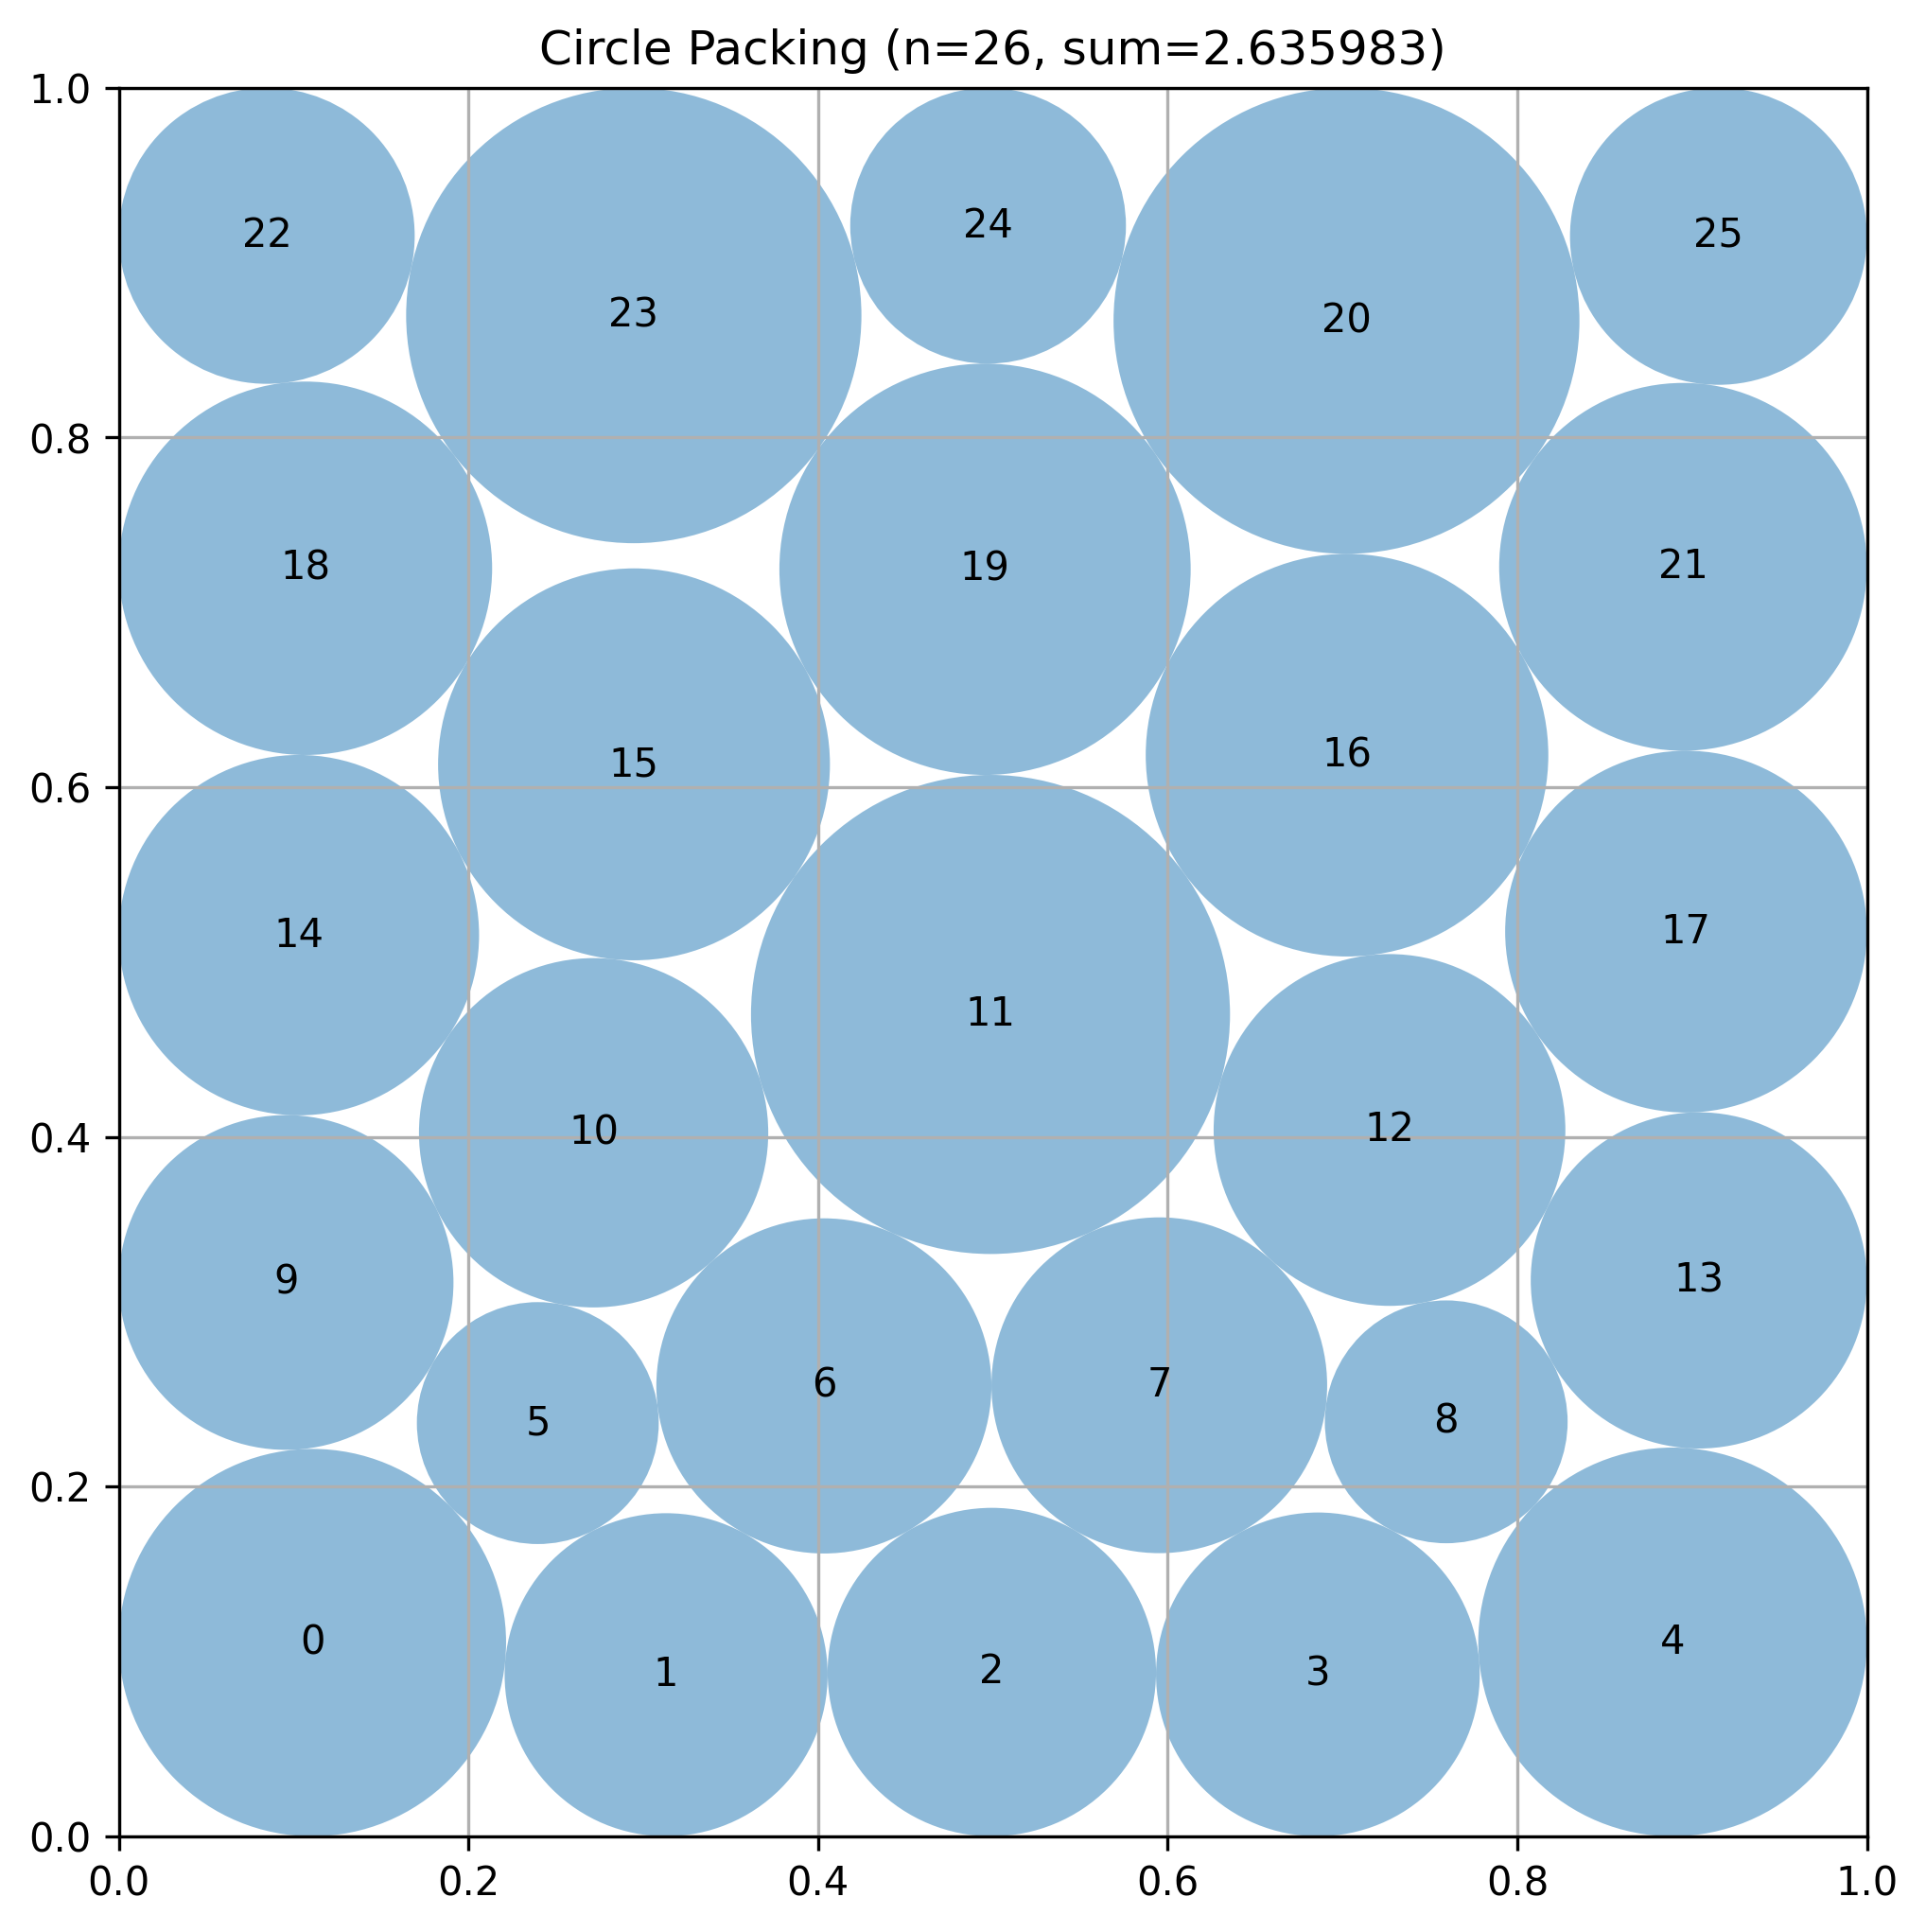

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# set high dpi for all figures
plt.rcParams["figure.dpi"] = 300


def visualize(centers, radii):
    """
    Visualize the circle packing

    Args:
        centers: np.array of shape (n, 2) with (x, y) coordinates
        radii: np.array of shape (n) with radius of each circle
    """
    fig, ax = plt.subplots(figsize=(8, 8))

    # Draw unit square
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.grid(True)

    # Draw circles
    for i, (center, radius) in enumerate(zip(centers, radii)):
        circle = Circle(center, radius, alpha=0.5)
        ax.add_patch(circle)
        ax.text(center[0], center[1], str(i), ha="center", va="center")

    ax.set_title(f"Circle Packing (n={len(centers)}, sum={sum(radii):.6f})")
    return fig, ax


fig, ax = visualize(centers, radii_adapted)
# store as pdf
fig.savefig("circle_packing_results_adapted.pdf", bbox_inches="tight", dpi=300)